# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Muhammad Irzam Hafis Fabiansyah | 5054251024 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan missing value
path = kagglehub.dataset_download('jamaltariqcheema/pima-indians-diabetes-dataset')
data = pd.read_csv(path + '/diabetes.csv')

print("Informasi Dataset:")
print(data.info())

print("\nJumlah Missing Value per Kolom:")
print(data.isnull().sum())

print("\nJumlah Duplikasi Baris:", data.duplicated().sum())

print("\nStatistik Deskriptif:")
display(data.describe())

print("\nBeberapa Baris Pertama Dataset:")
display(data.head())

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
None

Jumlah Missing Value per Kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



Beberapa Baris Pertama Dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


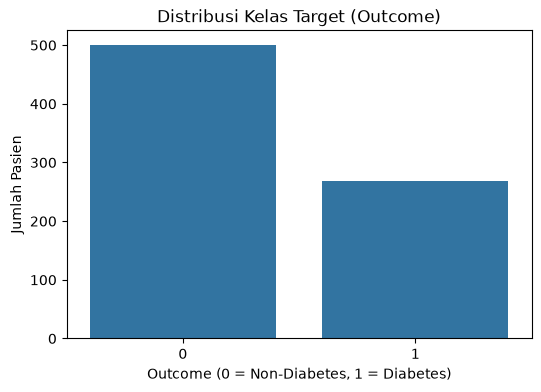

Proporsi Kelas Target:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [3]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=data)
plt.title('Distribusi Kelas Target (Outcome)')
plt.xlabel('Outcome (0 = Non-Diabetes, 1 = Diabetes)')
plt.ylabel('Jumlah Pasien')
plt.show()

print("Proporsi Kelas Target:")
print(data['Outcome'].value_counts(normalize=True))

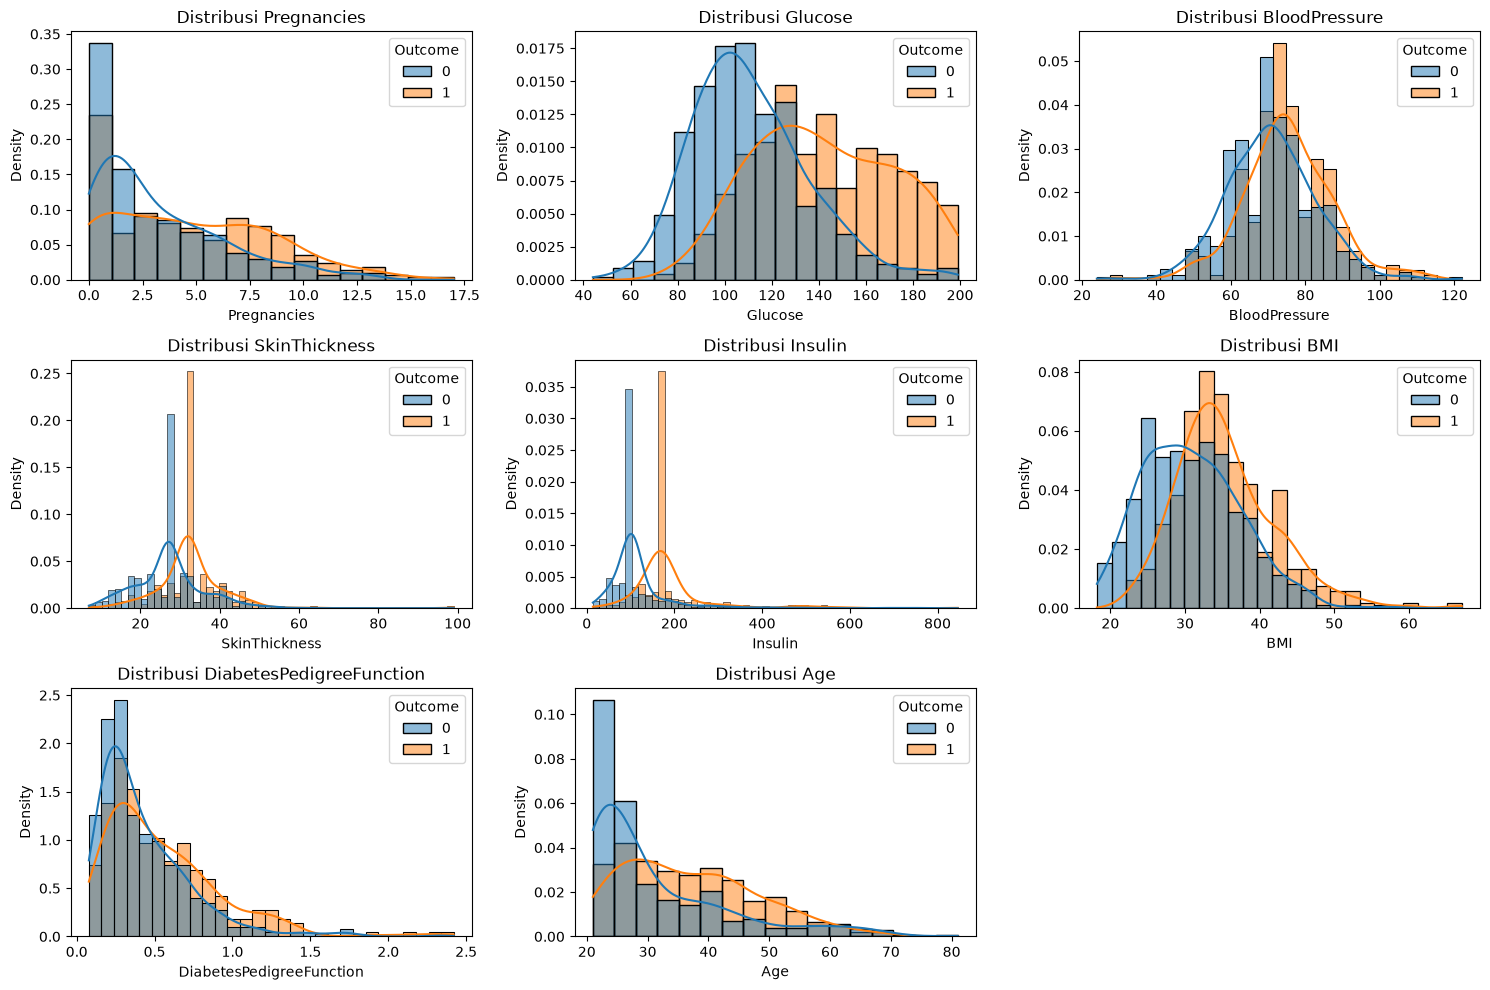

In [ ]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome
features = [col for col in data.columns if col != 'Outcome']
plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=data, x=col, hue='Outcome', kde=True, stat='density', common_norm=False)
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

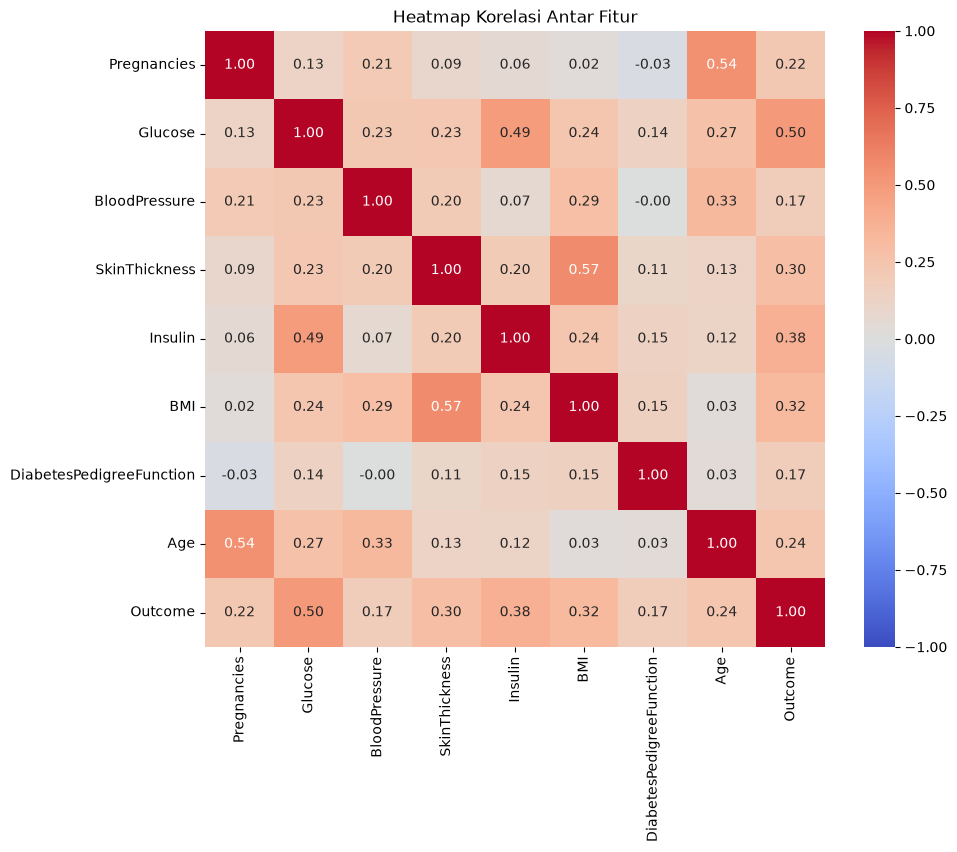

In [ ]:
# Tampilkan heatmap korelasi antar fitur
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

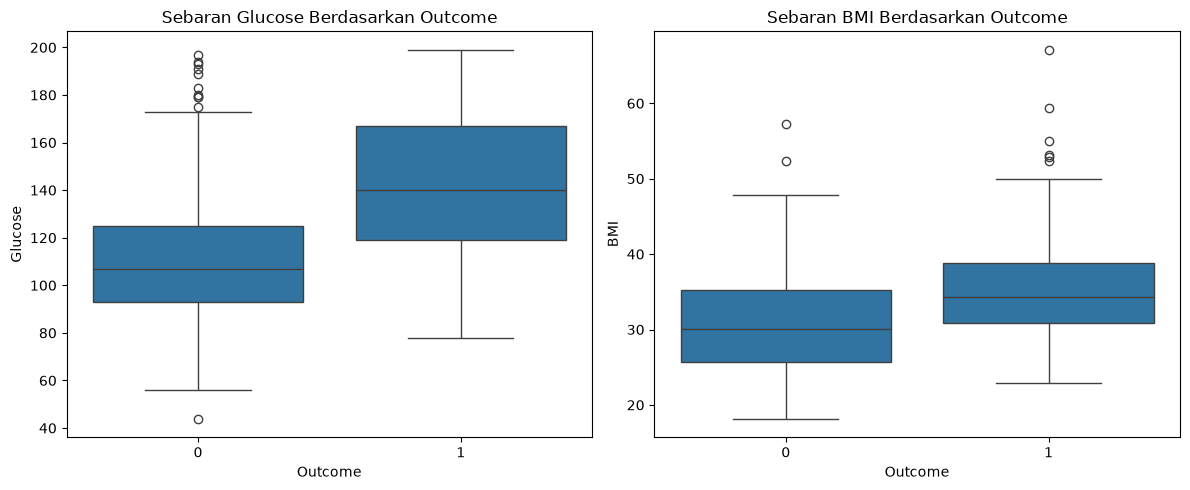

In [6]:
# EDA tambahan: Boxplot untuk melihat sebaran fitur utama terhadap Outcome
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Outcome', y='Glucose', data=data)
plt.title('Sebaran Glucose Berdasarkan Outcome')

plt.subplot(1, 2, 2)
sns.boxplot(x='Outcome', y='BMI', data=data)
plt.title('Sebaran BMI Berdasarkan Outcome')

plt.tight_layout()
plt.show()

# 2. Preprocessing

In [7]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Jumlah nilai 0 pada masing-masing kolom yang mencurigakan:")
for col in zero_cols:
    count_zero = (data[col] == 0).sum()
    pct_zero = (count_zero / len(data)) * 100
    print(f"{col}: {count_zero} ({pct_zero:.2f}%)")

Jumlah nilai 0 pada masing-masing kolom yang mencurigakan:
Glucose: 0 (0.00%)
BloodPressure: 0 (0.00%)
SkinThickness: 0 (0.00%)
Insulin: 0 (0.00%)
BMI: 0 (0.00%)


In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = data.drop(columns=['Outcome'])
y = data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Dimensi Train set:", X_train.shape)
print("Dimensi Test set:", X_test.shape)

Dimensi Train set: (614, 8)
Dimensi Test set: (154, 8)


In [9]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Imputasi dilakukan menggunakan median dari train set (nilai non-zero) lalu diterapkan ke train dan test set.
for col in zero_cols:
    median_val = X_train.loc[X_train[col] != 0, col].median()
    if pd.isna(median_val):
        median_val = X_train[col].median()
    X_train[col] = X_train[col].replace(0, median_val)
    X_test[col] = X_test[col].replace(0, median_val)

print("Pemeriksaan nilai 0 setelah imputasi pada X_train:")
print((X_train[zero_cols] == 0).sum())

Pemeriksaan nilai 0 setelah imputasi pada X_train:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [10]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [11]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
model_gnb = GaussianNB()
model_gnb.fit(X_train_scaled, y_train)

# Lakukan prediksi pada test set dan tampilkan classification report serta confusion matrix.
y_pred_gnb = model_gnb.predict(X_test_scaled)
print("Classification Report Gaussian Naive Bayes:")
print(classification_report(y_test, y_pred_gnb))

print("Confusion Matrix Gaussian Naive Bayes:")
print(confusion_matrix(y_test, y_pred_gnb))

Classification Report Gaussian Naive Bayes:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       100
           1       0.60      0.65      0.62        54

    accuracy                           0.73       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

Confusion Matrix Gaussian Naive Bayes:
[[77 23]
 [19 35]]


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = model_gnb.predict(X_test_scaled)
y_prob_gnb = model_gnb.predict_proba(X_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [13]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train_scaled, y_train)

# Lakukan prediksi pada test set dan tampilkan classification report serta confusion matrix.
y_pred_lr = model_lr.predict(X_test_scaled)
print("Classification Report Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix Logistic Regression:")
print(confusion_matrix(y_test, y_pred_lr))

Classification Report Logistic Regression:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154

Confusion Matrix Logistic Regression:
[[79 21]
 [24 30]]


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_lr = model_lr.predict(X_test_scaled)
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluasi Model

In [15]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
metrics_data = {
    'Model': ['Gaussian Naive Bayes', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gnb),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_gnb),
        precision_score(y_test, y_pred_lr)
    ],
    'Recall': [
        recall_score(y_test, y_pred_gnb),
        recall_score(y_test, y_pred_lr)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_gnb),
        f1_score(y_test, y_pred_lr)
    ]
}

df_eval = pd.DataFrame(metrics_data)
print("Perbandingan Metrik Evaluasi:")
display(df_eval)

Perbandingan Metrik Evaluasi:


,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian Naive Bayes,0.727273,0.603448,0.648148,0.625000
1,Logistic Regression,0.707792,0.588235,0.555556,0.571429


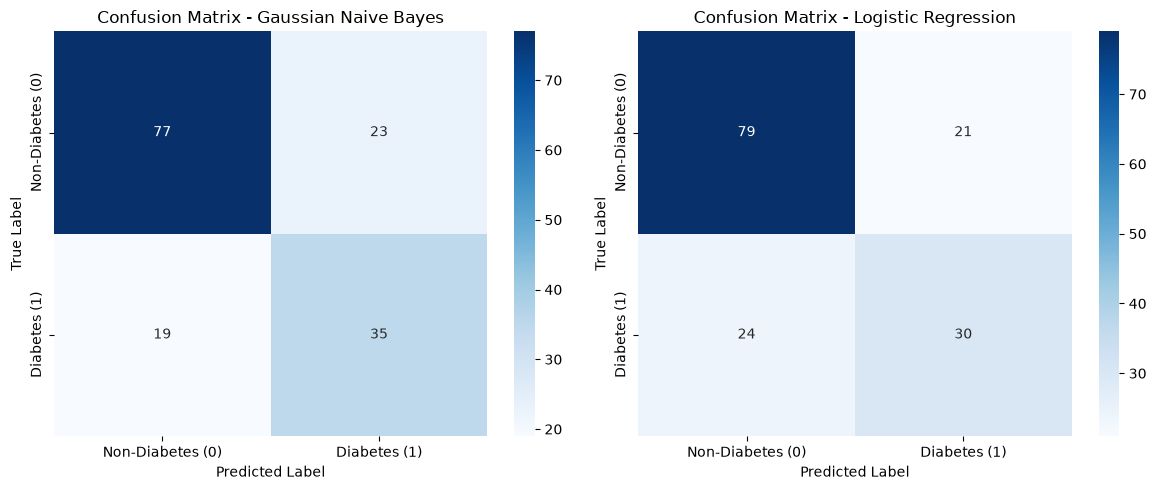

In [16]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model_preds = [
    ('Gaussian Naive Bayes', y_pred_gnb),
    ('Logistic Regression', y_pred_lr)
]

for ax, (name, pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Diabetes (0)', 'Diabetes (1)'],
                yticklabels=['Non-Diabetes (0)', 'Diabetes (1)'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

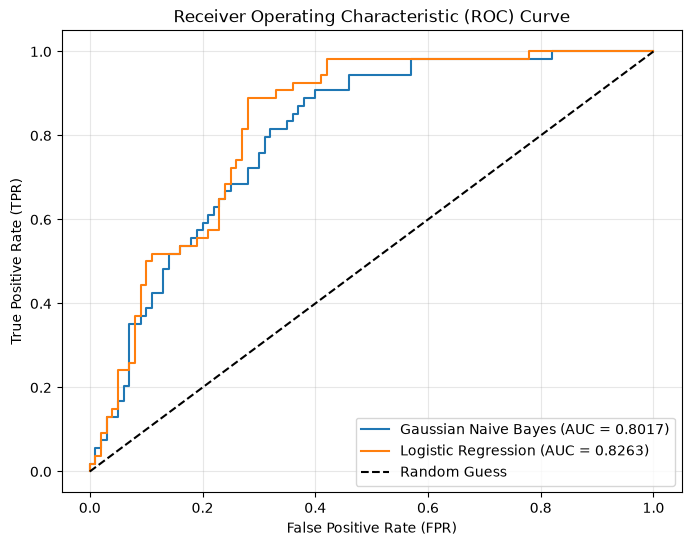

In [17]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
model_probs = [
    ('Gaussian Naive Bayes', y_prob_gnb),
    ('Logistic Regression', y_prob_lr)
]

plt.figure(figsize=(8, 6))

for name, prob in model_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

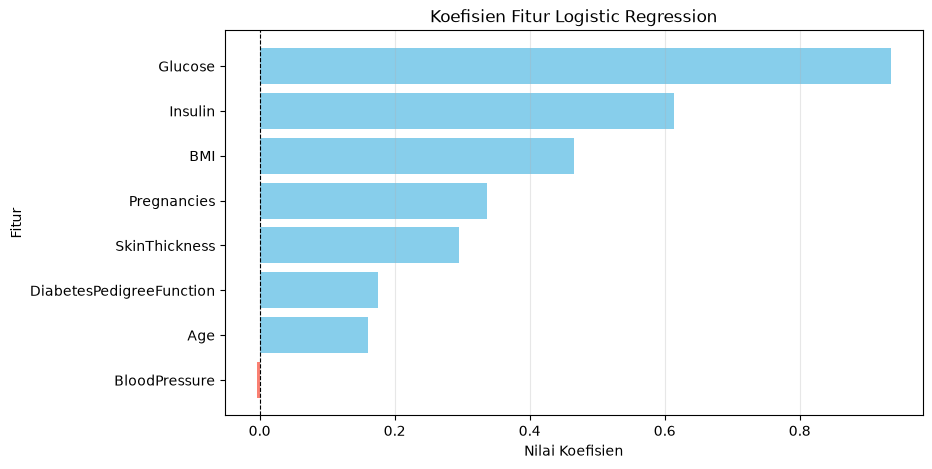

In [18]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_lr.coef_[0]
}).sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(9, 5))
colors = ['salmon' if c < 0 else 'skyblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Koefisien Fitur Logistic Regression')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.grid(axis='x', alpha=0.3)
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Gaussian Naive Bayes memberikan akurasi data uji yang lebih tinggi (72.73% dan F1-Score 62.50%) dibandingkan Logistic Regression (70.78% dan F1-Score 57.14%), serta recall yang lebih baik terhadap kelas diabetes (64.81% vs 55.56%). Namun, dari segi peringkat probabilitas, Logistic Regression menghasilkan nilai AUC yang sedikit lebih unggul (0.8263 vs 0.8017).

Berdasarkan analisis koefisien Logistic Regression, fitur `Glucose` dan `Insulin` menjadi prediktor positif paling dominan terhadap risiko diabetes, diikuti oleh `BMI` dan `Pregnancies`. Hal ini konsisten dengan fakta medis bahwa kadar gula darah dan resistensi insulin berlebih merupakan indikator utama penyakit diabetes.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Model terbaik untuk klasifikasi pada threshold standar adalah Gaussian Naive Bayes dengan akurasi 72.73% dan recall 64.81%, menjadikannya lebih sensitif dalam mendeteksi pasien diabetes dibandingkan Logistic Regression, sementara Logistic Regression unggul dalam interpretasi pengaruh fitur secara linear.